In [ ]:
#CODIGO QUE USABA EN CERN SWAN CON ARCHIVOS EN CERNBOX
from logfile import Logfile  # Importa la clase LogFile
from run_testSTS import Run  # Importa la clase Run que hemos creado
import pandas as pd

# 1. Cargar el logfile usando la clase LogFile

logfiles = Logfile(filepath="LogFile.csv")  # Esto lee el archivo CSV
logfile_df = logfiles.log_file  # Obtener el DataFrame cargado

# Ver los datos cargados del logfile
print("Logfile cargado:")
print(logfile_df.head())  # Mostrar las primeras filas del DataFrame




Archivo CSV cargado correctamente desde 'LogFile.csv'.
Logfile cargado:
                                        Filename Selection Liquid Media Type  \
0  20220201_ln2_r48176_r48177_487178-48189_pre_1       NaN          LN2  Pre   
1      20220201_ln2_r48176_r48177_487178-48189_1       BAD          LN2  Cal   
2  20220201_ln2_r48176_r48177_487178-48189_pre_2       BAD          LN2  Pre   
3      20220201_ln2_r48176_r48177_487178-48189_2       BAD          LN2  Cal   
4  20220201_ln2_r48176_r48177_487178-48189_pre_3       BAD          LN2  Pre   

  CalibSetNumber        Date StartTime HeatFinTime FinTime  REF1_ID  ...  \
0              0  01/02/2022     12:38         NaN   12:57  48176.0  ...   
1              1  01/02/2022     13:06         NaN   13:47  48176.0  ...   
2              0  01/02/2022     14:38         NaN   14:57  48176.0  ...   
3              1  01/02/2022     15:02         NaN   15:42  48176.0  ...   
4              0  01/02/2022     15:44       16:10   16:28  48176.0

In [13]:
# 1. Cargar el logfile usando la clase LogFile
logfiles = Logfile(filepath="LogFile.csv")  # Esto lee el archivo CSV
logfile_df = logfiles.log_file  # Obtener el DataFrame cargado

# Ver los datos cargados del logfile (opcional)
# print("Logfile cargado:")
# print(logfile_df.head())

# 2. Nombre del archivo de temperatura que quieres procesar
filename = "20251020_ln2_STSr10_STSr9_STS121-STS132_2"

# 1. Crear una instancia de la clase Run
run = Run(filename=filename, logfile=logfile_df)

###SON FUNCIONES QUE ESTÁN EN EL INIT Y SE REALIZAN DIRECTAMENTE AL CREAR LA INSTANCIA
# 2. Cargar el archivo de temperatura
#run.load_temperature_file()
#run.filter_faulty_channels()
# 3. Asociar los sensores con los canales de temperatura
#run.associate_sensors()

# 4. Imprimir el DataFrame con los datos procesados
print("Datos de temperatura con IDs de sensores asociados:")
print(run.temperature_data.head())  # Aquí accedes directamente al atributo de la instancia


Archivo CSV cargado correctamente desde 'LogFile.csv'.
Archivo de temperatura encontrado: /eos/user/j/jcapotor/RTDdata/Data/Frame_Sensors/CalSetN_F13/20251020_ln2_STSr10_STSr9_STS121-STS132_2.txt
Valores NaN (contador): 0
Empty DataFrame
Columns: [datetime, channel, value]
Index: []
Archivo de temperatura procesado correctamente: /eos/user/j/jcapotor/RTDdata/Data/Frame_Sensors/CalSetN_F13/20251020_ln2_STSr10_STSr9_STS121-STS132_2.txt
No se detectaron canales defectuosos.
Valores de sensores extraídos (antes de filtrado y conversión): [ 121.  122.  123.  124.  125.  126.  127.  128.  129.  130.  131.  132.
 1010. 1009.]
IDs de sensores después de la conversión: ['121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '1010', '1009']
Asociación de canales con IDs de sensores:
channel_1: Sensor ID 121
channel_2: Sensor ID 122
channel_3: Sensor ID 123
channel_4: Sensor ID 124
channel_5: Sensor ID 125
channel_6: Sensor ID 126
channel_7: Sensor ID 127
channel_8: S

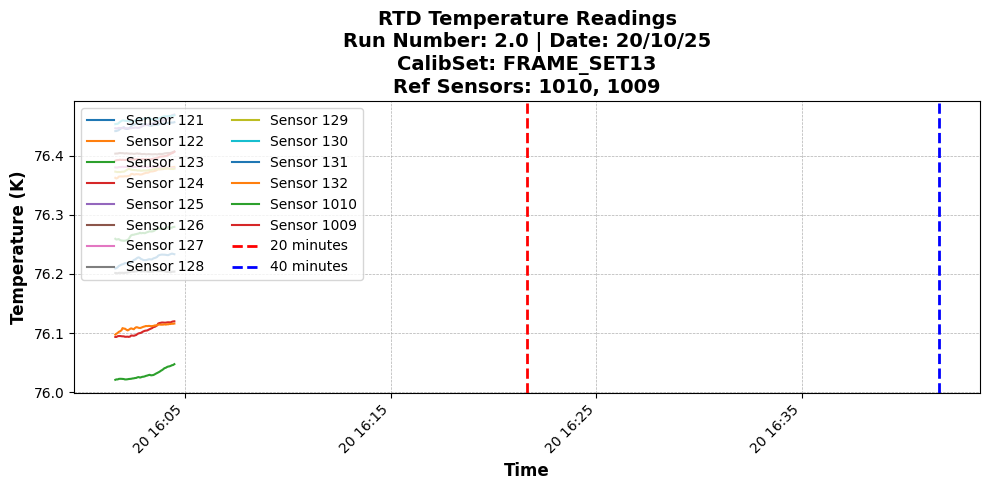

IndexError: index 0 is out of bounds for axis 0 with size 0

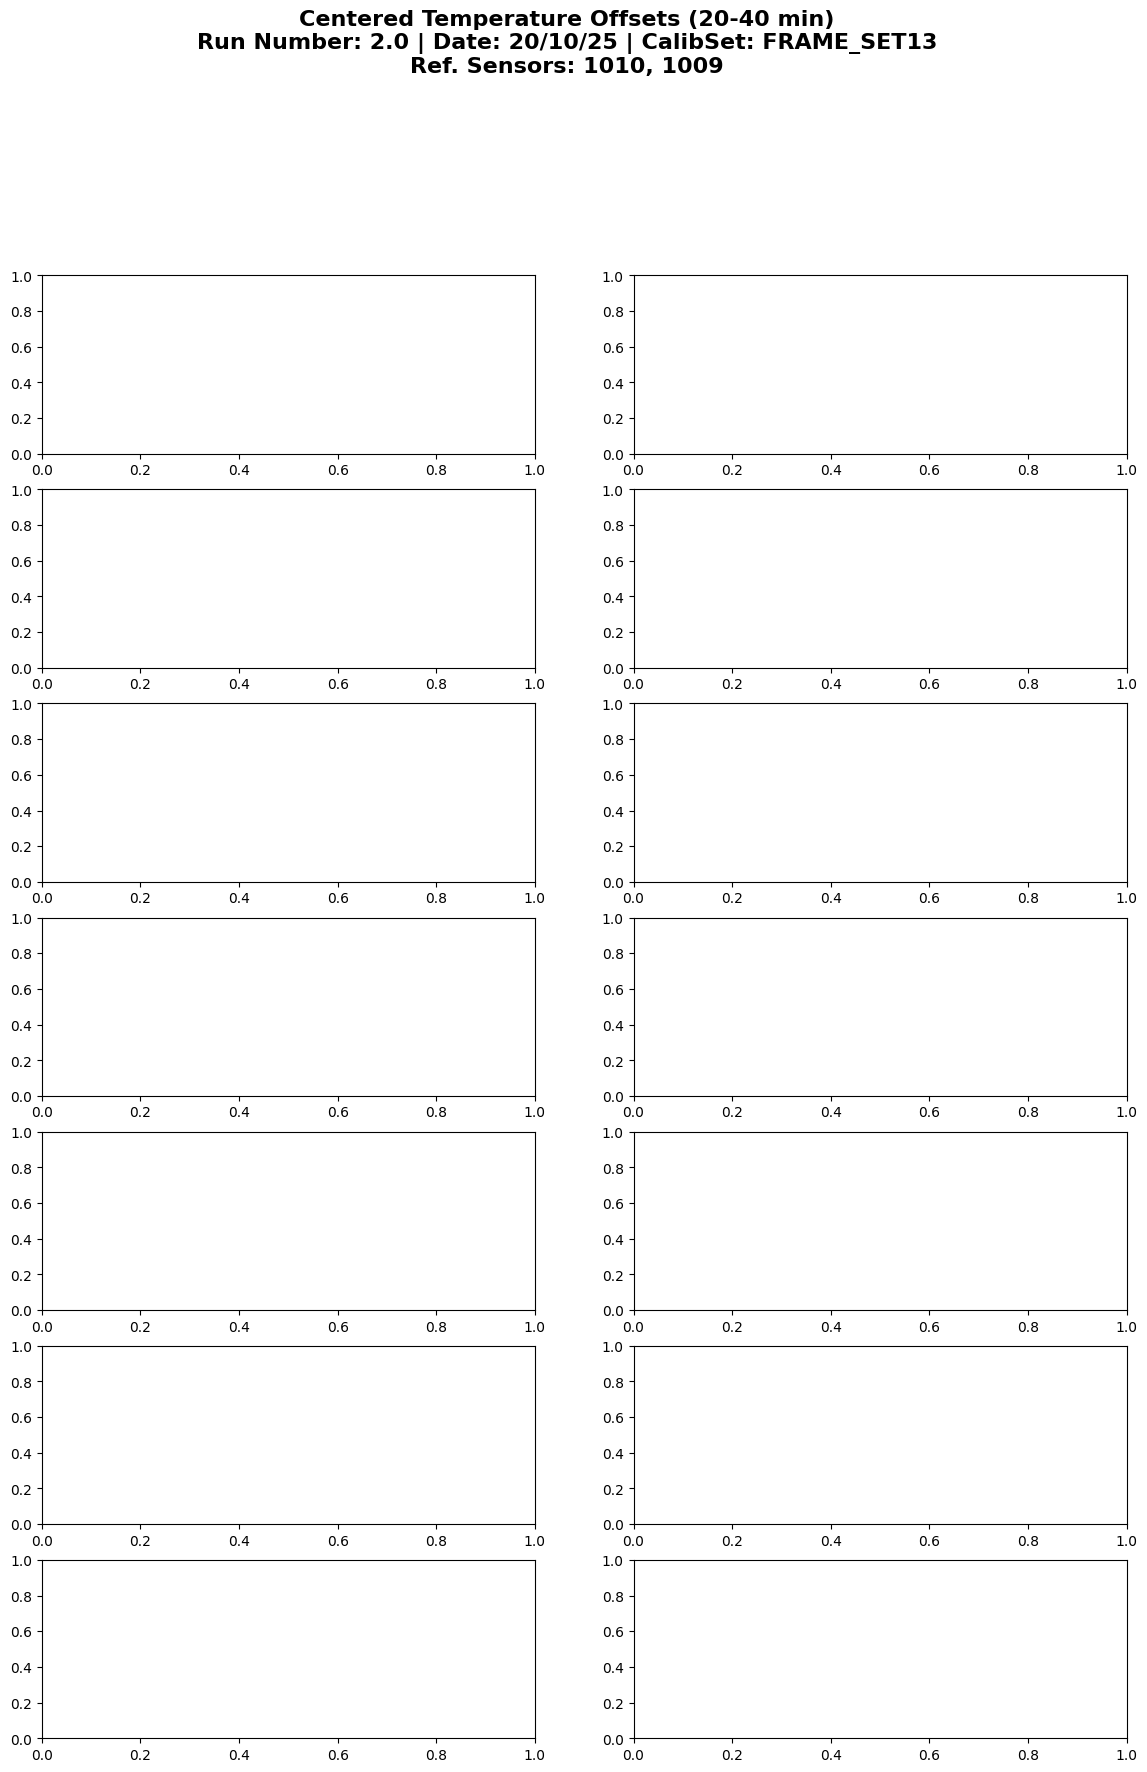

In [14]:
output_dir = "./Plots/"

run.save_control_plots(output_dir=output_dir)

print(f"Gráficos generados y guardados en: {output_dir}")

In [7]:
# Calcular offsets
offsets_df = run.offsets()
print("\nMatriz de Offsets (media entre sensores):")
print(offsets_df)

# Calcular errores (RMS)
errors_df = run.stat_err_offsets()
print("\nErrores RMS de Offsets:")
print(errors_df)

Offsets medios calculados exitosamente para el run.

Matriz de Offsets (media entre sensores):
           121       122       123       124       125       126       127  \
121   0.000000  0.081221  0.187087  0.342787 -0.012599  0.030168  0.052708   
122  -0.081221  0.000000  0.105866  0.261567 -0.093820 -0.051053 -0.028512   
123  -0.187087 -0.105866  0.000000  0.155701 -0.199686 -0.156919 -0.134379   
124  -0.342787 -0.261567 -0.155701  0.000000 -0.355387 -0.312620 -0.290079   
125   0.012599  0.093820  0.199686  0.355387  0.000000  0.042767  0.065307   
126  -0.030168  0.051053  0.156919  0.312620 -0.042767  0.000000  0.022540   
127  -0.052708  0.028512  0.134379  0.290079 -0.065307 -0.022540  0.000000   
128  -0.228754 -0.147534 -0.041667  0.114033 -0.241353 -0.198586 -0.176046   
129  -0.057170  0.024050  0.129917  0.285617 -0.069769 -0.027002 -0.004462   
130   0.027252  0.108473  0.214339  0.370039  0.014653  0.057420  0.079960   
131  -0.218502 -0.137281 -0.031415  0.124285 -0

Gráfico guardado en: ./Plots/20251020_ln2_STSr8_STSr9_STS109-STS120_4_rms_vs_time.png


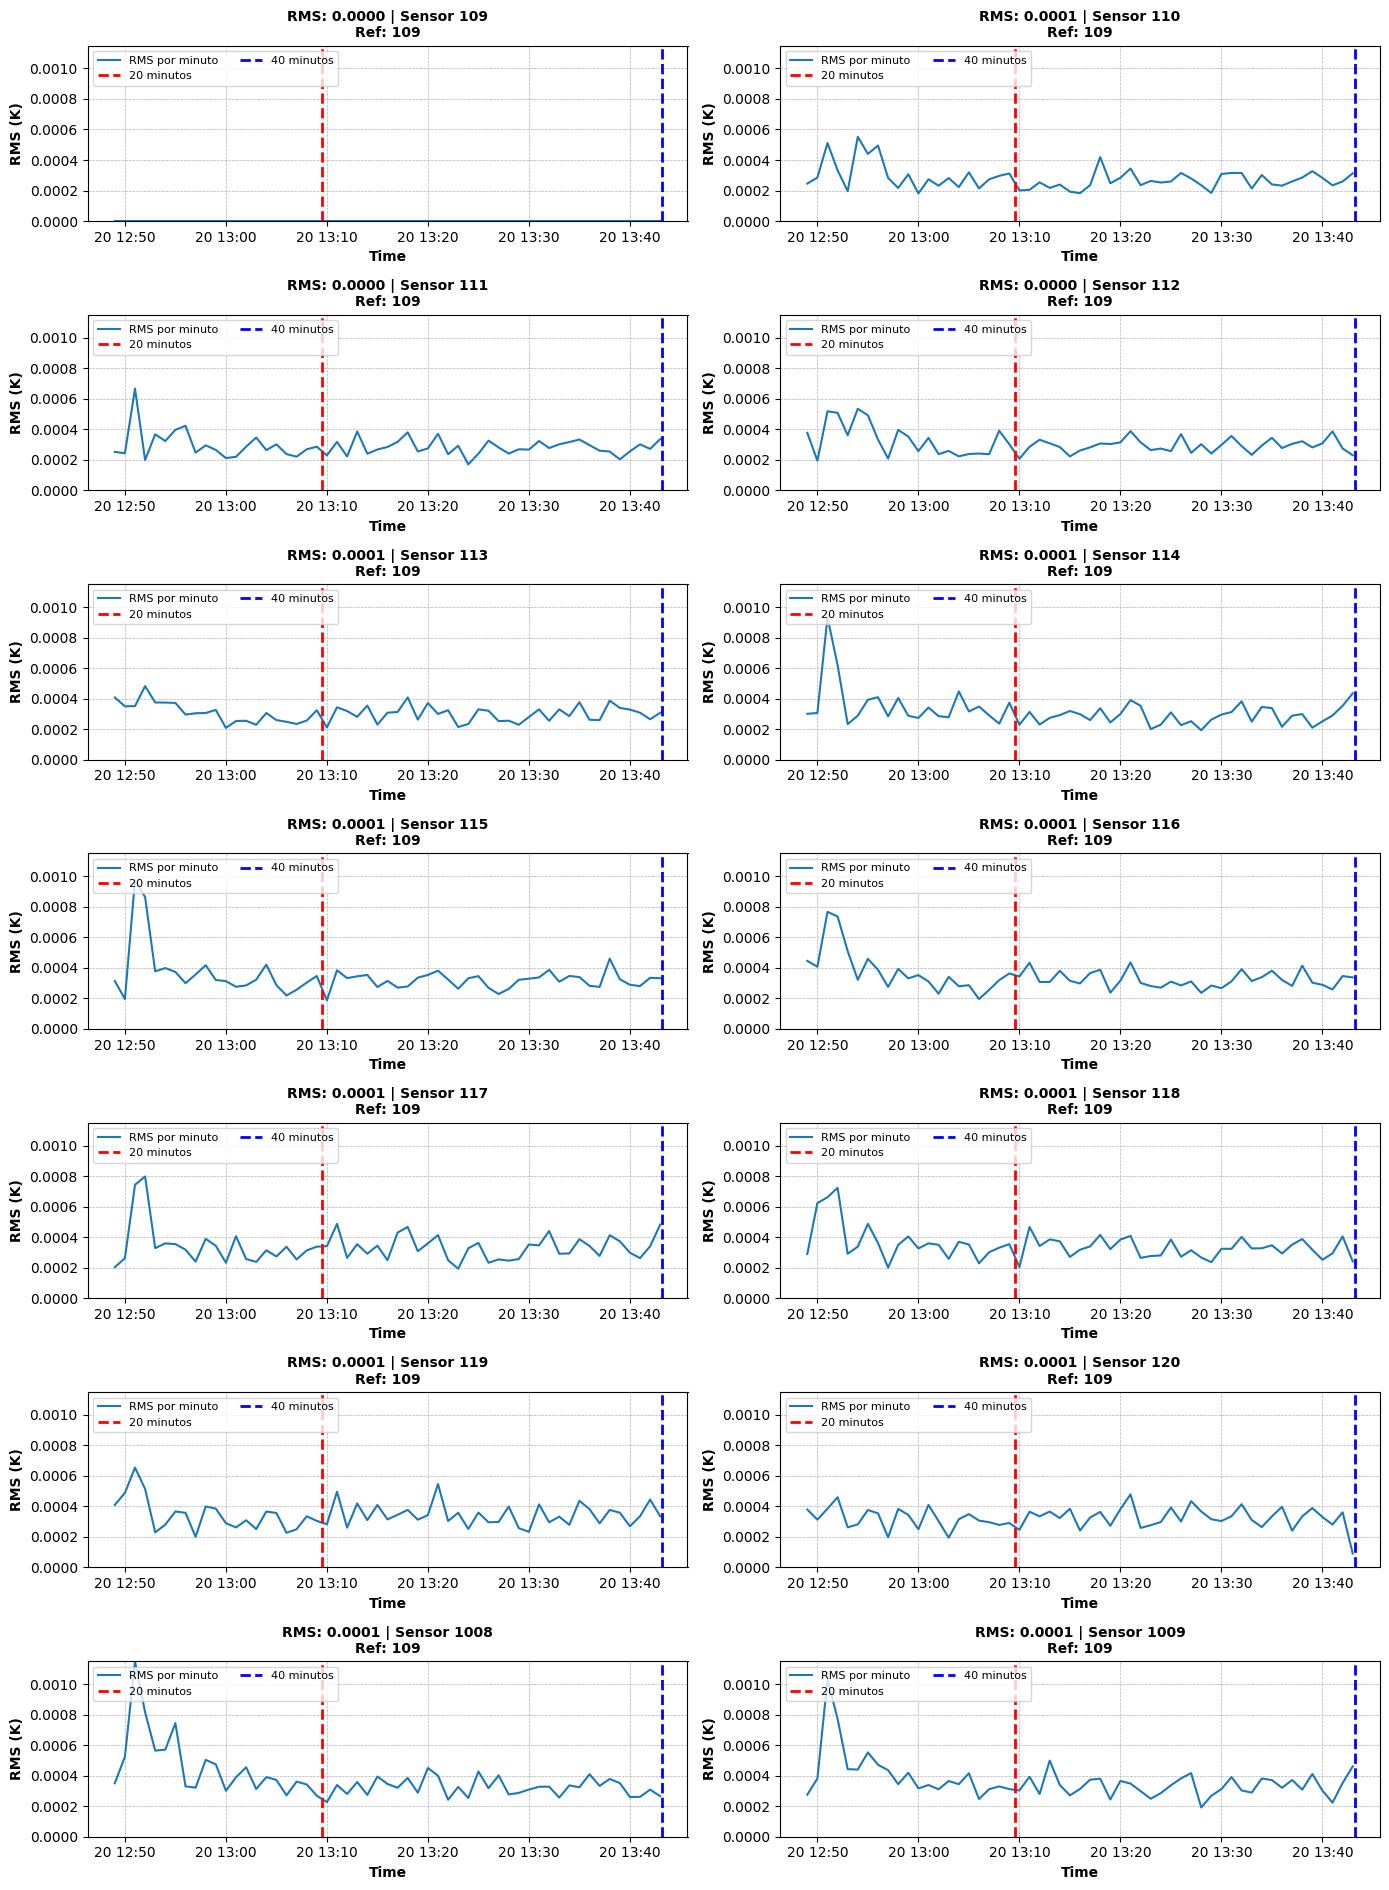

In [5]:
run.plot_rms_vs_time(output_dir= "./Plots/")